<a href="https://colab.research.google.com/github/va4756/deeplearn_practice/blob/main/pytorch_reinfoceL_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.char_rnn_classification

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1_1.기초부터 시작하는 NLP: 문자-단위 RNN으로 이름 생성하기

### 데이터 준비

In [8]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob
import os
import unicodedata
import string

In [9]:
all_letters = string.ascii_letters + " .,;'-"
n_letters = len(all_letters) + 1  # EOS(end of sentence) 기호 추가

In [10]:
def findFiles(path): return glob.glob(path)

In [11]:
# 유니코드 문자열을 ASCII로 변환
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

In [12]:
# 파일을 읽고 줄 단위로 분리
def readLines(filename):
    with open(filename, encoding='utf-8') as some_file:
        return [unicodeToAscii(line.strip()) for line in some_file]

In [13]:
# 각 언어의 이름 목록인 category_lines 사전 생성
category_lines = {}
all_categories = []
for filename in findFiles('/content/data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

In [14]:
if n_categories ==0:
    raise RuntimeError('Data not found. Make sure that you downloaded data '
        'from https://download.pytorch.org/tutorial/data.zip and extract it to '
        'the current directory.')

In [15]:
print('# categories:', n_categories, all_categories)
print(unicodeToAscii("O'Néàl"))

# categories: 18 ['Italian', 'Irish', 'German', 'Dutch', 'Greek', 'Chinese', 'Korean', 'Scottish', 'Portuguese', 'Spanish', 'Vietnamese', 'Arabic', 'Japanese', 'Czech', 'Russian', 'Polish', 'English', 'French']
O'Neal


### 네트워크 생성

In [16]:
import torch
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size

        self.i2h = nn.Linear(n_categories + input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(n_categories + input_size + hidden_size, output_size)
        self.o2o = nn.Linear(hidden_size + output_size, output_size)
        self.dropout = nn.Dropout(0.1)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, category, input, hidden):
        input_combined = torch.cat((category, input, hidden), 1)
        hidden = self.i2h(input_combined)
        output = self.i2o(input_combined)
        output_combined = torch.cat((hidden, output), 1)
        output = self.o2o(output_combined)
        output = self.dropout(output)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

### 학습

In [17]:
import random

# 목록에서 무작위 아이템 반환
def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

In [18]:
# 임의의 category 및 그 category에서 무작위 줄(이름) 얻기
def randomTrainingPair():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    return category, line

In [19]:
# Category를 위한 One-hot 벡터
def categoryTensor(category):
    li = all_categories.index(category)
    tensor = torch.zeros(1, n_categories)
    tensor[0][li] = 1
    return tensor

In [20]:
# 입력을 위한 처음부터 마지막 문자(EOS 제외)까지의  One-hot 행렬
def inputTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li in range(len(line)):
        letter = line[li]
        tensor[li][0][all_letters.find(letter)] = 1
    return tensor

In [21]:
# 목표를 위한 두번째 문자 부터 마지막(EOS)까지의 ``LongTensor``
def targetTensor(line):
    letter_indexes = [all_letters.find(line[li]) for li in range(1, len(line))]
    letter_indexes.append(n_letters - 1)  #EOS
    return torch.LongTensor(letter_indexes)

In [22]:
# 임의의 Category에서 Category, Input, Target Tensor를 만듬
def randomTrainingExample():
    category, line = randomTrainingPair()
    category_tensor = categoryTensor(category)
    input_line_tensor = inputTensor(line)
    target_line_tensor = targetTensor(line)
    return category_tensor, input_line_tensor, target_line_tensor

### 네트워크 학습

In [23]:
rnn = RNN(n_letters, 128, n_letters)

In [24]:
criterion = nn.NLLLoss()
learning_rate = 0.0005

def train(category_tensor, input_line_tensor, target_line_tensor):
    target_line_tensor.unsqueeze_(-1)
    hidden = rnn.initHidden()

    rnn.zero_grad()

    loss = torch.Tensor([0])

    for i in range(input_line_tensor.size(0)):
        output, hidden = rnn(category_tensor, input_line_tensor[i], hidden)
        l = criterion(output, target_line_tensor[i])
        loss += l

    loss.backward()

    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=learning_rate)

    return output, loss.item() / input_line_tensor.size(0)

In [25]:
import math
import time

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

In [26]:
# n_iters = 100000
n_iters = 10000
print_every = 5000
plot_every = 500
all_losses = []
total_loss = 0

In [27]:
start = time.time()

for iter in range(1, n_iters + 1):
    output, loss = train(*randomTrainingExample())
    total_loss += loss

    if iter % print_every == 0:
        print('%s (%d %d%%) %.4f' % (timeSince(start), iter, iter / n_iters * 100, loss))

    if iter % plot_every == 0:
        all_losses.append(total_loss / plot_every)
        total_loss = 0

0m 18s (5000 50%) nan
0m 36s (10000 100%) nan


### 손실 도식화

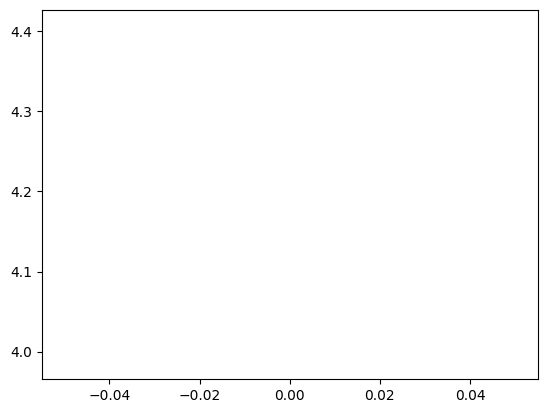

In [28]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(all_losses)

### 네트워크 샘플링

In [29]:
max_length = 20

# 카테고리와 시작 문자로부터 샘플링 하기
def sample(category, start_letter='A'):
    with torch.no_grad():  # 샘플링에서 히스토리를 추적할 필요 없음
        category_tensor = categoryTensor(category)
        input = inputTensor(start_letter)
        hidden = rnn.initHidden()

        output_name = start_letter

        for i in range(max_length):
            output, hidden = rnn(category_tensor, input[0], hidden)
            topv, topi = output.topk(1)
            topi = topi[0][0]
            if topi == n_letters - 1:
                break
            else:
                letter = all_letters[topi]
                output_name += letter
            input = inputTensor(letter)

        return output_name

In [30]:
# 하나의 카테고리와 여러 시작 문자들로 여러 개의 샘플 얻기
def samples(category, start_letters='ABC'):
    for start_letter in start_letters:
        print(sample(category, start_letter))

In [31]:
samples('Russian', 'RUS')

samples('German', 'GER')

samples('Spanish', 'SPA')

samples('Chinese', 'CHI')

RMMMMMMMMMMMMMMMMMMMM
UMMMMMMMMMMMMMMMMMMMM
SMMMMMMMMMMMMMMMMMMMM


# 2.Recurrent DQN: Training recurrent policies

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# https://github.com/pytorch/rl/blob/main/tutorials/sphinx-tutorials/dqn_with_rnn.py

In [5]:
import tempfile

In [7]:
!pip3 install torchrl
!pip install gymnasium[mujoco]
!pip3 install tqdm

In [8]:
import gymnasium as gym

import warnings
warnings.filterwarnings("ignore")

In [9]:
from torch import multiprocessing

if multiprocessing.get_start_method(allow_none=True) is None:
    multiprocessing.set_start_method("fork")

In [10]:
import torch
import tqdm
from tensordict.nn import (
    TensorDictModule as Mod,
    TensorDictSequential,
    TensorDictSequential as Seq,
)
from torch import nn
from torchrl.collectors import Collector
from torchrl.data import LazyMemmapStorage, TensorDictReplayBuffer
from torchrl.data.replay_buffers.samplers import SliceSampler
from torchrl.envs import (
    Compose,
    ExplorationType,
    GrayScale,
    InitTracker,
    ObservationNorm,
    Resize,
    RewardScaling,
    set_exploration_type,
    StepCounter,
    ToTensorImage,
    TransformedEnv,
)
from torchrl.envs.libs.gym import GymEnv
from torchrl.modules import ConvNet, EGreedyModule, LSTMModule, MLP, QValueModule
from torchrl.objectives import DQNLoss, SoftUpdate

In [13]:
is_fork = multiprocessing.get_start_method() == 'fork'
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
print(device)

cpu


In [14]:
env = TransformedEnv(
    GymEnv("CartPole-v1", from_pixels=True, device=device),
    Compose(
        ToTensorImage(),
        GrayScale(),
        Resize(84, 84),
        StepCounter(),
        InitTracker(),
        RewardScaling(loc=0.0, scale=0.1),
        ObservationNorm(standard_normal=True, in_keys=["pixels"]),
    ),
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: De

In [15]:
env.transform[-1].init_stats(1000, reduce_dim=[0, 1, 2], cat_dim=0, keep_dims=[0])
td = env.reset()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
# Policy
feature = Mod(
    ConvNet(
        num_cells=[32, 32, 64],
        squeeze_output=True,
        aggregator_class=nn.AdaptiveAvgPool2d,
        aggregator_kwargs={"output_size": (1,1)},
        device=device
    ),
    in_keys=["pixels"],
    out_keys=["embed"]
)

In [17]:
n_cells = feature(env.reset())["embed"].shape[-1]

In [18]:
# LSTM Module
lstm = LSTMModule(
    input_size=n_cells,
    hidden_size=128,
    device=device,
    in_key="embed",
    out_key="embed"
)

In [19]:
print("in keys", lstm.in_keys)
print("out keys", lstm.out_keys)

in keys ['embed', 'recurrent_state_h', 'recurrent_state_c', 'is_init']
out keys ['embed', ('next', 'recurrent_state_h'), ('next', 'recurrent_state_c')]


In [20]:
env.append_transform(lstm.make_tensordict_primer())

TransformedEnv(
    env=GymEnv(env=CartPole-v1, batch_size=torch.Size([]), device=cpu),
    transform=Compose(
            ToTensorImage(keys=['pixels']),
            GrayScale(keys=['pixels']),
            Resize(w=84, h=84, interpolation=InterpolationMode.BILINEAR, keys=['pixels']),
            StepCounter(keys=[]),
            InitTracker(keys=[]),
            RewardScaling(loc=0.0000, scale=0.1000, keys=['reward']),
            ObservationNorm(keys=['pixels']),
            TensorDictPrimer(primers=Composite(
                recurrent_state_h: UnboundedContinuous(
                    shape=torch.Size([1, 128]),
                    space=ContinuousBox(
                        low=Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, contiguous=True),
                        high=Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, contiguous=True)),
                    device=cpu,
                    dtype=torch.float32,
                    domain=continu

In [21]:
print(env)

TransformedEnv(
    env=GymEnv(env=CartPole-v1, batch_size=torch.Size([]), device=cpu),
    transform=Compose(
            ToTensorImage(keys=['pixels']),
            GrayScale(keys=['pixels']),
            Resize(w=84, h=84, interpolation=InterpolationMode.BILINEAR, keys=['pixels']),
            StepCounter(keys=[]),
            InitTracker(keys=[]),
            RewardScaling(loc=0.0000, scale=0.1000, keys=['reward']),
            ObservationNorm(keys=['pixels']),
            TensorDictPrimer(primers=Composite(
                recurrent_state_h: UnboundedContinuous(
                    shape=torch.Size([1, 128]),
                    space=ContinuousBox(
                        low=Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, contiguous=True),
                        high=Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, contiguous=True)),
                    device=cpu,
                    dtype=torch.float32,
                    domain=continu

In [22]:
# MLP
mlp = MLP(
    out_features=2,
    num_cells = [64, ],
    device=device
)

In [23]:
mlp[-1].bias.data.fill_(0.0)
mlp = Mod(mlp, in_keys=["embed"], out_keys=["action_value"])

In [26]:
# Using the Q-Values to select an action
qval = QValueModule(action_space=None, spec=env.action_spec)

In [27]:
policy = Seq(feature, lstm, mlp, qval)

In [28]:
exploration_module = EGreedyModule(
    annealing_num_steps=1_000_000, spec=env.action_spec, eps_init=0.2, device=device
)
stoch_policy = TensorDictSequential(
    policy,
    exploration_module,
)

In [29]:
# Using the model for the loss
policy(env.reset())

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([2]), device=cpu, dtype=torch.int64, is_shared=False),
        action_value: Tensor(shape=torch.Size([2]), device=cpu, dtype=torch.float32, is_shared=False),
        chosen_action_value: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        embed: Tensor(shape=torch.Size([128]), device=cpu, dtype=torch.float32, is_shared=False),
        is_init: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields={
                recurrent_state_c: Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, is_shared=False),
                recurrent_state_h: Tensor(shape=torch.Size([1, 128]), device=cpu, dtype=torch.float32, is_shared=False)},
            batch_size=torch.Size([]),
            device=cpu,
            is_shared=False),

In [30]:
# DQN Loss
loss_fn = DQNLoss(policy, action_space=env.action_spec, delay_value=True)

In [31]:
updater = SoftUpdate(loss_fn, eps=0.95)

In [32]:
optim = torch.optim.Adam(policy.parameters(), lr=3e-4)

In [33]:
# Collector and replay buffer
buffer_scratch_dir = tempfile.TemporaryDirectory().name

In [34]:
from functools import cache
rb = TensorDictReplayBuffer(
    storage=LazyMemmapStorage(1_000_000, scratch_dir=buffer_scratch_dir),
    sampler=SliceSampler(
        slice_len=50, end_key=("next", "done"), cache_values=True, strict_length=False
    ),
    batch_size=200,
    prefetch=10,
    transform=lambda td: td.to(device),
)

In [35]:
collector = Collector(
    env,
    stoch_policy,
    frames_per_batch=50,
    total_frames=200,
    storing_device="cpu",
    replay_buffer=rb,
)

In [36]:
# Training loop
utd = 16
pbar = tqdm.tqdm(total=collector.total_frames)
longest = 0

traj_lens = []
for i, _ in enumerate(collector):
    pbar.update(collector.frames_per_batch)
    # Only start training once we have enough data in the buffer
    if len(rb) < 1000:
        continue
    for j in range(utd):
        s = rb.sample()
        if i == 0 and j == 0:
            # Let's print the first sample to see the data structure
            print(
                "Let us print the first batch of sampled data from the replay buffer.\n"
                "Pay attention to the key names which will reflect what can be found in this data structure, "
                "in particular: the output of the QValueModule (action_values, action and chosen_action_value),"
                "the 'is_init' key that will tell us if a step is initial or not, and the "
                "recurrent_state keys.\n",
                s,
            )
        loss_vals = loss_fn(s)
        loss_vals["loss"].backward()
        optim.step()
        optim.zero_grad()
    pbar.set_description(
        f"buffer_size: {len(rb)}, loss_val: {loss_vals['loss'].item(): 4.4f}"
    )
    exploration_module.step(collector.frames_per_batch)
    updater.step()

    with set_exploration_type(ExplorationType.DETERMINISTIC), torch.no_grad():
        rollout = env.rollout(10000, stoch_policy)
        traj_lens.append(rollout.get(("next", "step_count")).max().item())

  0%|          | 0/200 [00:00<?, ?it/s]

2026-07-13 19:46:18,305 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([1000000]) shape [END]


100%|██████████| 200/200 [00:03<00:00, 60.65it/s]

In [38]:
# plot our results
if traj_lens:
    from matplotlib import pyplot as plt

    plt.plot(traj_lens)
    plt.xlabel("Test collection")
    plt.title("Test trajectory lengths")

In [39]:
# Remove scratch dir
try:
    import shutil

    # Use shutil.rmtree() to delete the directory and all its contents
    shutil.rmtree(buffer_scratch_dir)
    print(f"Directory '{buffer_scratch_dir}' deleted successfully.")
except FileNotFoundError:
    print(f"Directory '{buffer_scratch_dir}' not found.")
except Exception as e:
    print(f"Error deleting directory: {e}")
# sphinx_gallery_end_ignore

Directory '/tmp/tmpi_z9wtg5' deleted successfully.
